In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install shap


[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier

import shap


c:\Users\kdivy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Load dataset
data = pd.read_csv(r'C:\Users\kdivy\OneDrive\Desktop\COMP ANA HT DATA\COMP HT project\heart_attack_prediction_dataset.csv')

# Check available columns
print(data.columns)
# 4. Define Features and Target
# Drop unnecessary string columns + Target
X = data.drop(['Patient ID', 'Country', 'Continent', 'Hemisphere', 'Heart Attack Risk'], axis=1)
y = data['Heart Attack Risk']

# 5. Convert X to numeric if needed (VERY IMPORTANT)
X = X.apply(pd.to_numeric, errors='coerce')

# 6. Handle any missing values if they appear after conversion
X = X.fillna(0)  # (or use X = X.dropna() if you prefer)

# 7. Now split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 8. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Check
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')
X_train shape: (7010, 21)
X_test shape: (1753, 21)
y_train shape: (7010,)
y_test shape: (1753,)



Training Logistic Regression...


c:\Users\kdivy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


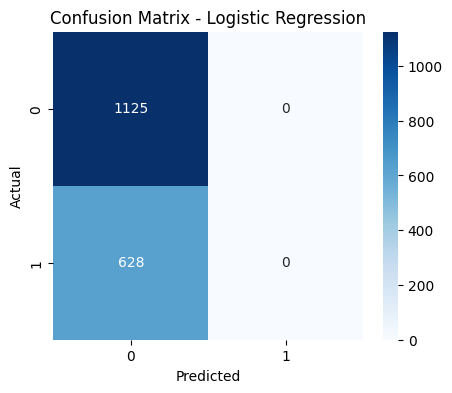


Training Naive Bayes...


c:\Users\kdivy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


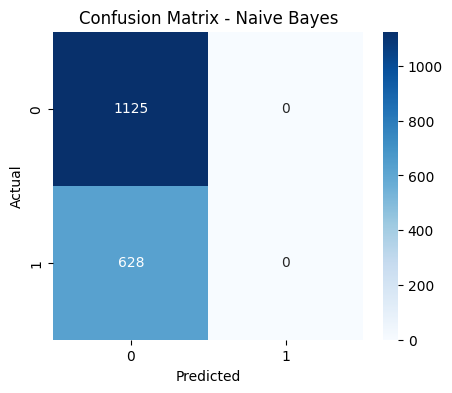


Training Decision Tree...


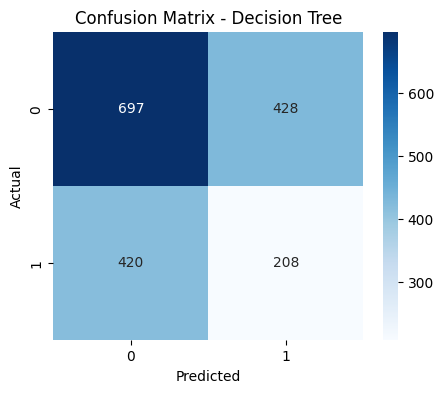


Training AdaBoost...


c:\Users\kdivy\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


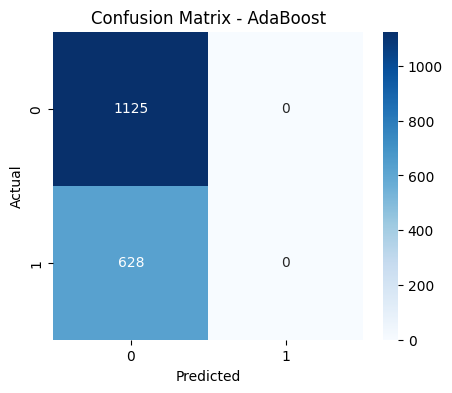


Training Random Forest...


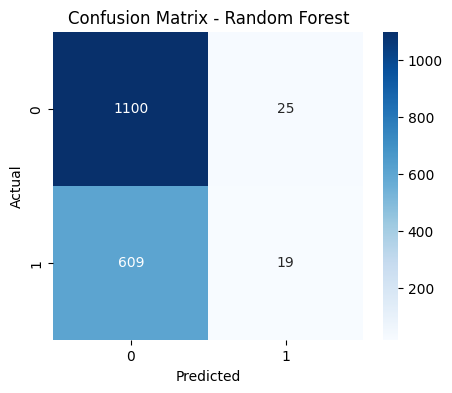


Training Bagging Classifier...


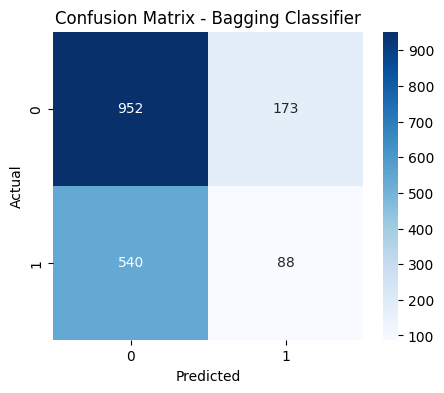

In [22]:
# 1. Import more models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier

# 2. Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
import shap

# 3. Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Bagging Classifier': BaggingClassifier()
}

# 4. Dictionary to store results
results = {}

# 5. Train models
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    if name in ['Logistic Regression', 'Naive Bayes']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, probs)
    
    results[name] = [acc, prec, rec, f1, auc]
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


Model Comparison Table:
                     Accuracy  Precision    Recall  F1-Score       AUC
Logistic Regression  0.641757   0.000000  0.000000  0.000000  0.492234
Naive Bayes          0.641757   0.000000  0.000000  0.000000  0.498549
Decision Tree        0.516258   0.327044  0.331210  0.329114  0.475383
AdaBoost             0.641757   0.000000  0.000000  0.000000  0.501752
Random Forest        0.638334   0.431818  0.030255  0.056548  0.515086
Bagging Classifier   0.593269   0.337165  0.140127  0.197975  0.481410


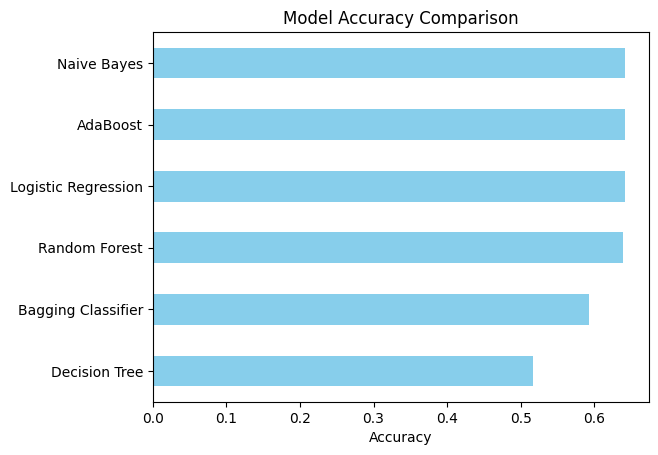

In [23]:
# Results table
results_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']).T
print("\nModel Comparison Table:")
print(results_df)

# Bar plot for Accuracy
results_df['Accuracy'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.show()


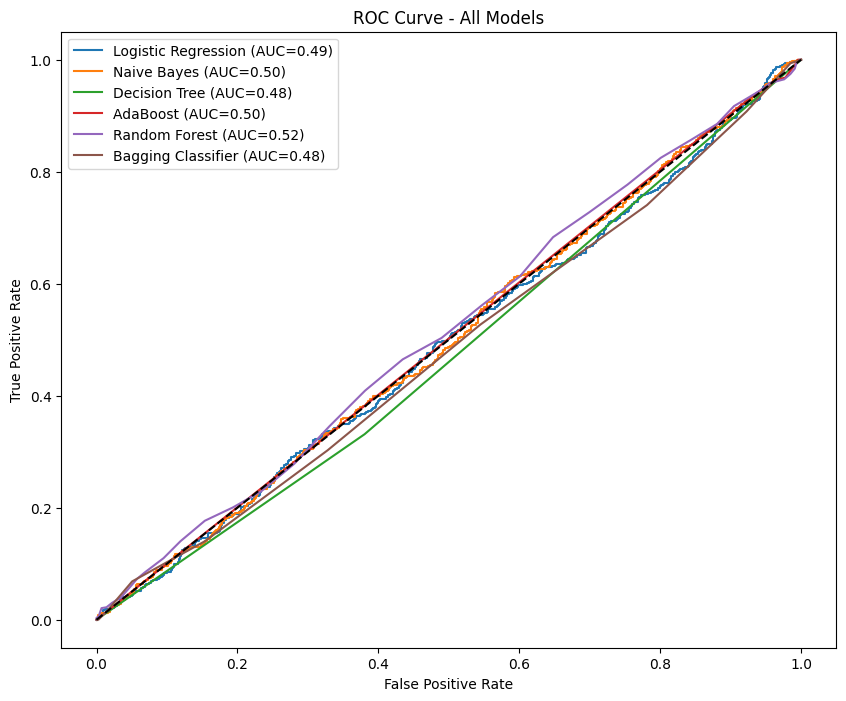

In [24]:
plt.figure(figsize=(10,8))
for name, model in models.items():
    if name in ['Logistic Regression', 'Naive Bayes']:
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        probs = model.predict_proba(X_test)[:,1]
        
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, probs):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.show()